## Load Packages
We begin by loading all the required packages for ML and visualization.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from plotnine import *
from great_tables import GT
from quarto import theme_brand_plotnine, theme_brand_great_tables
from brand_yml import *

In [ ]:
#| code-fold: true

# my_brand = Brand.from_yaml(path='_brand.yml')
plot_theme = theme_brand_plotnine('_brand.yml')
table_theme = theme_brand_great_tables('_brand.yml')
theme_set(theme_minimal() + theme(
    dpi = 100,
    figure_size = (8, 6),
    plot_title = element_text(size = 15),
    axis_text = element_text(size = 12),
    axis_title = element_text(size = 13)
  ))
color_palette = {
    "discrete1": ["#6E2DAB", "#49752E", "#FFB300", "#D7263D", "#008B8B"],
    "discrete2": ["#9B79CD", "#2F4F4F", "#B0C4DE", "#DAA520", "#A52A2A"], 
    "sequential1": ["#EFEFF8", "#C7BDE0", "#9B79CD", "#6E2DAB", "#522180"], 
    "sequential2": ["#EBF5E7", "#B8D3A8", "#82B471", "#49752E", "#30511F"], 
    "sequential3": ["#FFF8E1", "#FFDDA1", "#FFB300", "#CC8C00", "#996600"], 
    "diverging1": ["#A50F15", "#D7263D", "#F49C8F", "#FDF7EC", "#A5D6A7", "#49752E","#284A1A"], 
    "diverging2": ["#522180", "#6E2DAB", "#B6A0D9", "#FDF7EC", "#FFDDA1", "#FFB300","#CC8C00"]
}

## Load Data
The next step is to load the `iris` dataset from the `scikit-learn` module:

In [3]:
# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

In addition to getting the target and features above, we also create a combined data frame for visualization:

In [4]:
# Create a DataFrame for easier manipulation
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)
(
    GT(df.head())
    .tab_header(title="Iris Flowers")
).tab_options(**table_theme)

GT(_tbl_data=   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  , _body=<great_tables._gt_data.Body object at 0x000001676CD15010>, _boxhead=Boxhead([ColInfo(var='sepal length (cm)', type=<ColInfoTypeEnum.default: 1>, column_label='sepal length (cm)', column_align='right', column_width=None), ColInfo(var='sepal width (cm)', type=<ColInfoTypeEnum.default: 1>, column_label='sepal width (cm)', column_align='right', column_width=None), ColInfo(var='petal length (cm)', type=<ColInfoTypeEnum.default: 1>, column_label='petal length (cm)', column_align='right', column_width=None), ColInfo(var='petal width (cm)', type=<ColInfoTypeEnum.default: 1>, column_label='petal width (cm)', column_align='right', column_width=None), ColInfo(var='species', type=<ColInfoTypeEnum.default: 1>, column_label='species', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000016759C16FD0>, _spanners=Spanners([]), _heading=Heading(title='Iris Flowers', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001676CDCA0D0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001676CDCA450>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001676CDCA610>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#EFEFF8'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#1B2D0B'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_s

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [6]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"Model Accuracy: {accuracy:.2%}")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [9]:
# Create confusion matrix for visualization
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame({
    'Actual': np.repeat(iris.target_names, 3),
    'Predicted': np.tile(iris.target_names, 3),
    'Count': cm.flatten()
})

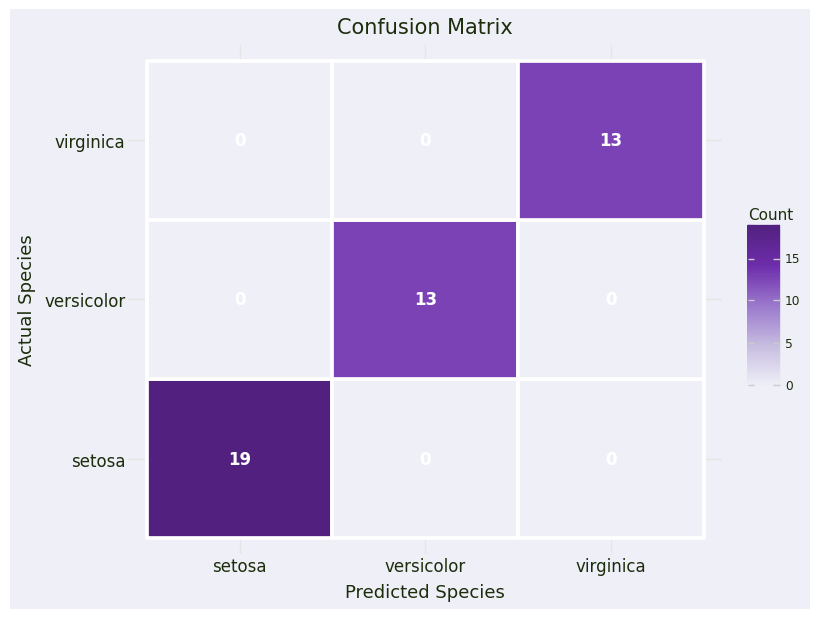

In [10]:
# Plot 1: Confusion Matrix
confusion_plot = (
    ggplot(cm_df, aes(x='Predicted', y='Actual', fill='Count')) +
    geom_tile(color='white', size=1.5) +
    geom_text(aes(label='Count'), color='white', size=12, fontweight='bold') +
    scale_fill_gradientn(colors=color_palette["sequential1"]) +
    labs(title='Confusion Matrix', x='Predicted Species', y='Actual Species') +
    plot_theme
)

confusion_plot

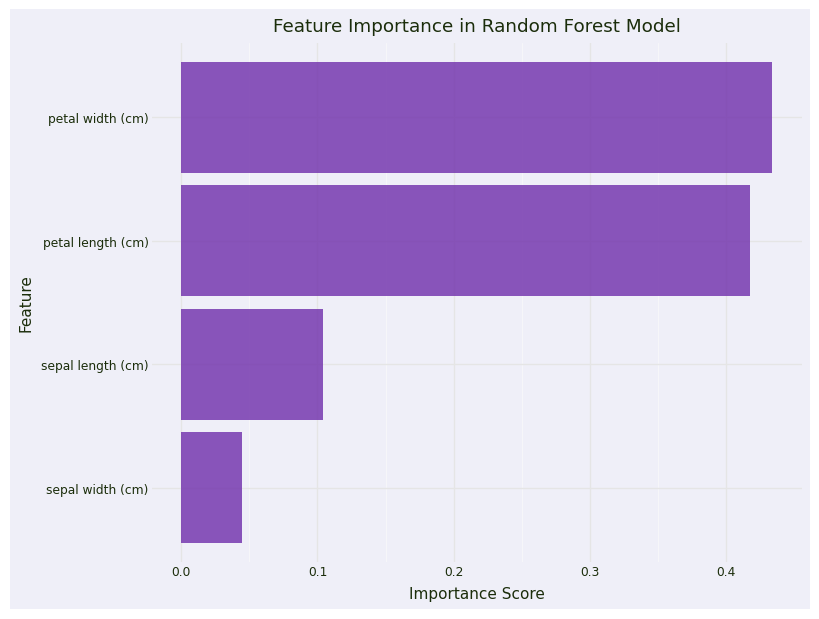

In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot 2: Feature Importance
importance_plot = (
    ggplot(feature_importance, aes(x='reorder(feature, importance)', y='importance')) +
    geom_col(fill=color_palette["discrete1"][0], alpha=0.8) +
    coord_flip() +
    labs(title='Feature Importance in Random Forest Model',
         x='Feature',
         y='Importance Score') +
    theme_minimal() +
    theme(figure_size=(8, 6))
)

importance_plot + plot_theme

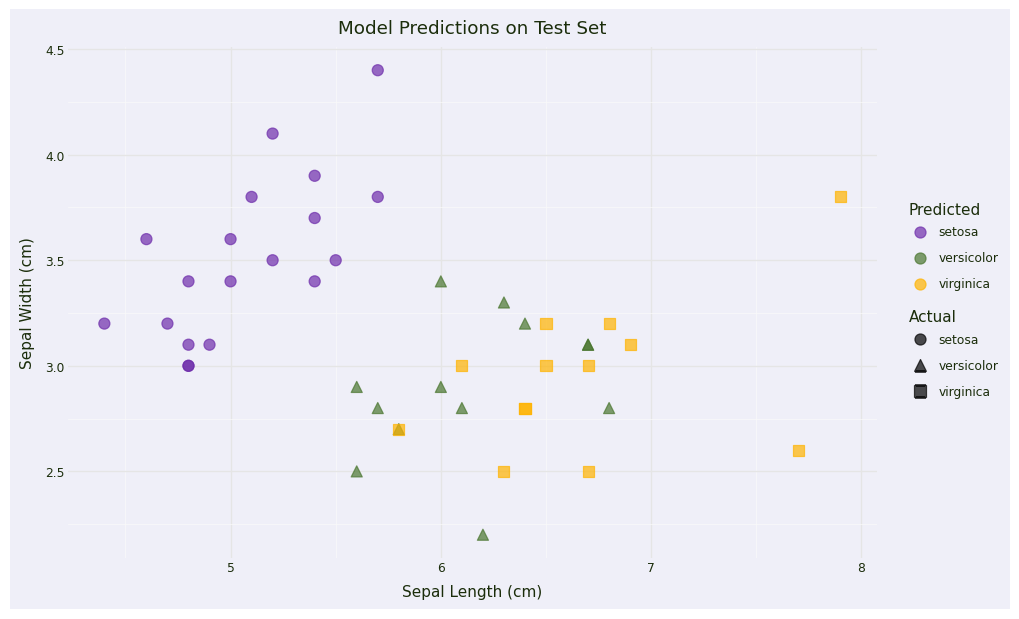

In [12]:
# Create predictions DataFrame for visualization
test_results = pd.DataFrame(X_test, columns=iris.feature_names)
test_results['actual'] = pd.Categorical.from_codes(y_test, iris.target_names)
test_results['predicted'] = pd.Categorical.from_codes(y_pred, iris.target_names)
test_results['correct'] = test_results['actual'] == test_results['predicted']

# Plot 3: Prediction Results (using first two features)
prediction_plot = (
    ggplot(test_results, aes(x='sepal length (cm)', y='sepal width (cm)', 
                              color='predicted', shape='actual')) +
    geom_point(size=4, alpha=0.7) +
    scale_color_manual(values=color_palette["discrete1"]) +
    labs(title='Model Predictions on Test Set',
         x='Sepal Length (cm)',
         y='Sepal Width (cm)',
         color='Predicted',
         shape='Actual') +
    theme_minimal() +
    theme(figure_size=(10, 6))
)

prediction_plot + plot_theme